## Main notebook script for PV shadow analysis.

Uses the refactored pv_analysis module with:
  - SiteConfig with inverter_utc_offset_hours=3 (confirmed fixed UTC+3)
  - Pre-smoothed shadow matrix (done once)
  - Beam/diffuse separated shadow attenuation
  - Robust timezone handling (no magic-number offsets)
  - No duplicate evaluation loops
  - Validated inverter data loading with gap reporting

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MANUSCRIPT_FIG_DIR = Path("/Users/hdong/Projects/VoxSolaris_Article/figs")
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})


from pv_analysis_re import (
    SiteConfig,
    find_clear_days,
    load_and_smooth_shadow_matrix,
    load_extra_data_csv,
    load_inverter_data,
    pv_analysis,
    _plot_day_comparison,
    compute_metrics,
    evaluate_performance,
    print_performance_summary,
    plot_real_vs_predicted_scatter,
    save_all_day_plots,
    calculate_api_grid,
    plot_api_map,
)

# Project modules (unchanged)
from shadow_matrix_simulation_re import create_shadow_matrix
# from plot_radiation_day import plot_radiation_day
# from batch_day_plots import batch_radiation_plots, batch_day_plots
try:
    from visual_utils import plot_shadow_matrix_with_sunpaths
except ImportError:
    plot_shadow_matrix_with_sunpaths = None

In [2]:
cfg = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=12.0,
    azimuth_deg=170.0,
    nominal_power_kw=3.96,  # 15% derating for system losses (cabling, inverter inefficiency, etc.)
    system_efficiency=0.8,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,  # Fronius Symo logs in fixed UTC+3
    forecast_shift_minutes=-30, # Shift forecasts 30 minutes earlier to better align with measured data
    window_size=(3, 3),
    interval="5min",
    interval_minutes=5.0,
)

# --- File Paths ---
RAD_FILE       = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TEMP_WIND_FILE = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
CLEAR_MINUTES  = "data/Clear_sky_minutes_kuopio_RH16.txt"
PV_EXCEL       = "data/pvdata/pv_21.xlsx"

LIDAR_FILE     = "output/reclassified_final_v5.laz"
SHADOW_DIR     = "results/shadow_matrix_results_SE_pro"
SHADOW_FN      = "shadow_attenuation_matrix_conecasting_SE_v10.csv"
SHADOW_CSV     = f"{SHADOW_DIR}/{SHADOW_FN}"
EXTRA_DATA_DIR = "output"

In [3]:
# %% --- 1. Find Clear Days ---
clear_days = find_clear_days(CLEAR_MINUTES, threshold=1.05)
print(clear_days.head())

Found 10 clear days (threshold: Q3 + 1.05 * IQR = 735.438 minutes, mode=line_count)
          Date  LineCount  ClearMinutes
72  2021-07-03        914           914
73  2021-07-04        872           872
50  2021-06-09        821           821
52  2021-06-11        801           801
30  2021-05-13        796           796


In [4]:
# %% --- Reviewer TODO: 03_Site_Data.tex §Clear-Sky Day Selection ---
# Re-rank clear days using fraction of clear minutes within daylight hours
# rather than raw clear-minute counts.
# At high latitudes, summer days have up to 19 h of daylight, so a day
# with 800 raw clear minutes may be less 'clear' than a shorter day with 700.
#
# find_clear_days() already supports ranking_mode='daylight_fraction'.
# Run this cell and compare the two date sets.
#
# TODO[author]: If the set changes, update the selected days, Table text,
#   and derived metrics. If unchanged, add a note confirming robustness.

clear_days_fraction = find_clear_days(
    CLEAR_MINUTES,
    threshold=0.85, # Adjust threshold for fraction mode (e.g., 85% clear)
    ranking_mode="daylight_fraction",
    latitude=cfg.latitude,
    longitude=cfg.longitude,
    timestamp_tz="UTC",
    daylight_altitude_deg=0.0,
)

lc_dates = set(str(d) for d in clear_days["Date"])
fr_dates = set(str(d) for d in clear_days_fraction["Date"])

print("\n" + "=" * 55)
print("  CLEAR-SKY DAY SELECTION — COMPARISON")
print("=" * 55)
print(f"  Line-count mode  ({len(lc_dates):2d} days): {sorted(lc_dates)}")
print(f"  Fraction mode    ({len(fr_dates):2d} days): {sorted(fr_dates)}")

added = fr_dates - lc_dates
removed = lc_dates - fr_dates
if not added and not removed:
    print("\n  >>> SAME SET: daylight-fraction ranking selects identical days.")
    print("      TODO[author]: Confirm this result in the manuscript.")
else:
    print(f"\n  >>> SET CHANGED: +{len(added)} new | -{len(removed)} removed")
    if added:
        print(f"      Added:   {sorted(added)}")
    if removed:
        print(f"      Removed: {sorted(removed)}")
    print("  >>> TODO[author]: Decide whether to use 'fraction' ranking")
    print("      and update the manuscript accordingly.")

frac_cols = [c for c in ["Date", "ClearMinutes", "DaylightMinutes", "ClearFraction"]
             if c in clear_days_fraction.columns]
if frac_cols:
    print("\n  Daylight-fraction ranking (top 12 rows):")
    print(clear_days_fraction[frac_cols].head(12).to_string(index=False))


Found 10 clear days (threshold: Q3 + 0.85 * IQR = 0.689 fraction, mode=daylight_fraction)

  CLEAR-SKY DAY SELECTION — COMPARISON
  Line-count mode  (10 days): ['2021-05-12', '2021-05-13', '2021-06-04', '2021-06-09', '2021-06-10', '2021-06-11', '2021-07-03', '2021-07-04', '2021-07-14', '2021-07-26']
  Fraction mode    (10 days): ['2021-04-16', '2021-04-17', '2021-04-19', '2021-05-12', '2021-05-13', '2021-06-09', '2021-07-03', '2021-07-04', '2021-07-26', '2021-09-27']

  >>> SET CHANGED: +4 new | -4 removed
      Added:   ['2021-04-16', '2021-04-17', '2021-04-19', '2021-09-27']
      Removed: ['2021-06-04', '2021-06-10', '2021-06-11', '2021-07-14']
  >>> TODO[author]: Decide whether to use 'fraction' ranking
      and update the manuscript accordingly.

  Daylight-fraction ranking (top 12 rows):
      Date  ClearMinutes  DaylightMinutes  ClearFraction
2021-04-17           710            903.0       0.786268
2021-04-19           716            916.0       0.781659
2021-04-16           69

In [5]:
clear_days_fraction.describe()

,LineCount,ClearMinutes,DaylightMinutes,ClearFraction
count,10.000000,10.000000,10.00000,10.000000
mean,756.900000,756.900000,1018.30000,0.744871
std,112.482542,112.482542,160.70819,0.034735
min,510.000000,510.000000,702.00000,0.689751
25%,711.500000,711.500000,906.25000,0.728838
50%,769.000000,769.000000,1059.00000,0.749291
75%,814.750000,814.750000,1159.50000,0.770774
max,914.000000,914.000000,1190.00000,0.786268


In [6]:
import pvlib

def replace_dni_with_computed(df_extra, latitude, longitude):
    """
    Replace CAMS DNI with DNI computed from GHI, DHI, and solar zenith.
    Uses pvlib closure: DNI = (GHI - DHI) / cos(zenith)
    """
    solpos = pvlib.solarposition.get_solarposition(
        df_extra.index, latitude, longitude
    )
    zenith = solpos["apparent_zenith"]

    dni_computed = pvlib.irradiance.dni(
        ghi=df_extra["ghi"],
        dhi=df_extra["dhi"],
        zenith=zenith,
        # clearsky_dni=None,       # no clearsky limit
        # clearsky_tolerance=1.1,
    )

    df_extra["dni_cams"] = df_extra["dni"].copy()  # keep original
    df_extra["dni"] = dni_computed.clip(lower=0)

    return df_extra

In [7]:
def _load_cached_extra(date_obj):
    df = load_extra_data_csv(f"output/extra_data_{date_obj}.csv")
    df = replace_dni_with_computed(df, cfg.latitude, cfg.longitude)
    return df

In [8]:
# %% --- 2. Load & Inspect Extra Data for First Clear Day ---
second_day = clear_days["Date"].iloc[1]
extra_data_df = load_extra_data_csv(f"{EXTRA_DATA_DIR}/extra_data_{second_day}.csv", cfg=cfg, recompute_albedo=True)
print(extra_data_df.head())

                           dni   dhi   ghi      T  wind  albedo
time                                                           
2021-07-04 00:00:00+00:00  0.0  0.00 -0.36  18.10  0.72     0.2
2021-07-04 00:05:00+00:00  0.0  0.02  0.02  18.08  0.96     0.2
2021-07-04 00:10:00+00:00  0.0  0.60  0.30  18.36  1.48     0.2
2021-07-04 00:15:00+00:00  0.0  1.68  0.48  19.12  1.82     0.2
2021-07-04 00:20:00+00:00  0.0  2.14  1.22  19.20  1.16     0.2


In [9]:
# %% --- Reviewer TODO: 03_Site_Data.tex §DNI Overshoot Screening ---
# Generate a candidate DNI quality-control flag report for the full season.
# Flags produced (all configurable):
#   low_solar_elevation      — elevation < min_solar_elevation_deg (default 5°)
#   negative_ghi / dhi       — unphysical negative irradiance
#   dhi_gt_ghi               — diffuse exceeds global irradiance
#   dni_above_static_limit   — only if max_dni_wm2 is set
#   dni_above_clearsky_ratio — only if max_clearsky_ratio is set
#
# TODO[author]: After reviewing output/dni_qc_report_revised.csv, confirm:
#   1. Was any low-elevation or overshoot screening applied in the analysis?
#   2. If yes: document the criterion (e.g., elevation < 5°) and flagged-sample
#      counts in Section 3.4 of the manuscript.
#   3. If no: discuss as a data-quality limitation.
# Thresholds must be confirmed from the reference paper before any filtering.

from build_extra_data import build_dni_qc_report, summarize_dni_qc

# FMI Kuopio Savilahti station coordinates (source of irradiance measurements)
FMI_LAT, FMI_LON = 62.8924, 27.6353

qc_report = build_dni_qc_report(
    rad_csv=RAD_FILE,
    temp_wind_csv=TEMP_WIND_FILE,
    latitude=FMI_LAT,
    longitude=FMI_LON,
    start_date="2021-04-01",
    end_date="2021-09-30",
    resample_min=5,
    min_solar_elevation_deg=5.0,   # TODO[author]: confirm threshold from reference paper
    max_dni_wm2=None,              # TODO[author]: set if a static upper bound was applied
    max_clearsky_ratio=None,       # TODO[author]: set if a clearsky-ratio test was applied
    output_csv="output/dni_qc_report_revised.csv",
)

print("\nDNI QC Summary — full season (Apr-Sep 2021, 5-min data):")
print(summarize_dni_qc(qc_report).to_string())
print("\nFull flag report saved to: output/dni_qc_report_revised.csv")
print("TODO[author]: Review 'low_solar_elevation' count and document in manuscript.")


Saved DNI QC candidate report: output/dni_qc_report_revised.csv
low_solar_elevation         20398
negative_ghi                16097
negative_dhi                    0
dhi_gt_ghi                   2411
dni_above_static_limit          0
dni_above_clearsky_ratio        0
requires_manual_review      21425
total_samples               52704

DNI QC Summary — full season (Apr-Sep 2021, 5-min data):
low_solar_elevation         20398
negative_ghi                16097
negative_dhi                    0
dhi_gt_ghi                   2411
dni_above_static_limit          0
dni_above_clearsky_ratio        0
requires_manual_review      21425
total_samples               52704

Full flag report saved to: output/dni_qc_report_revised.csv
TODO[author]: Review 'low_solar_elevation' count and document in manuscript.


In [10]:
from datetime import date

# selected_day = date(2021, 7, 26)
# second_day = clear_days["Date"].iloc[1]  # Use second clear day
# selected_day = clear_days["Date"].iloc[1]  # Use second clear day
extra_data_df = load_extra_data_csv(f"{EXTRA_DATA_DIR}/extra_data_{second_day}.csv", cfg=cfg, recompute_albedo=True)
extra_data_df = replace_dni_with_computed(extra_data_df, cfg.latitude, cfg.longitude)
print(extra_data_df[["ghi", "dhi", "dni_cams", "dni"]].head())

                            ghi   dhi  dni_cams  dni
time                                                
2021-07-04 00:00:00+00:00 -0.36  0.00       0.0  NaN
2021-07-04 00:05:00+00:00  0.02  0.02       0.0 -0.0
2021-07-04 00:10:00+00:00  0.30  0.60       0.0  NaN
2021-07-04 00:15:00+00:00  0.48  1.68       0.0  NaN
2021-07-04 00:20:00+00:00  1.22  2.14       0.0  NaN


In [11]:
extra_data_df = replace_dni_with_computed(extra_data_df, cfg.latitude, cfg.longitude)
print(extra_data_df[["ghi", "dhi", "dni_cams", "dni"]].head())

                            ghi   dhi  dni_cams  dni
time                                                
2021-07-04 00:00:00+00:00 -0.36  0.00       NaN  NaN
2021-07-04 00:05:00+00:00  0.02  0.02      -0.0 -0.0
2021-07-04 00:10:00+00:00  0.30  0.60       NaN  NaN
2021-07-04 00:15:00+00:00  0.48  1.68       NaN  NaN
2021-07-04 00:20:00+00:00  1.22  2.14       NaN  NaN


In [12]:
# %% --- 3. Create Shadow Matrix (ray-tracing — slow, run once) ---
# Uncomment to regenerate:
# shadow_matrix_raw = create_shadow_matrix(
#     lidar_file_path=LIDAR_FILE, voxel_size=2.0,
#     output_dir=SHADOW_DIR, output_fn=SHADOW_FN,
#     offset_from_roof=-0.5, skip_dist=3.0,
# )


# %% --- 4. Load & Pre-smooth Shadow Matrix (done ONCE) ---
shadow_matrix = load_and_smooth_shadow_matrix(SHADOW_CSV, window_size=cfg.window_size)
print(f"Shadow matrix shape: {shadow_matrix.shape}  (altitude x azimuth)")

Shadow matrix shape: (91, 361)  (altitude x azimuth)


Loading shadow matrix...
Calculating seasonal sun paths...


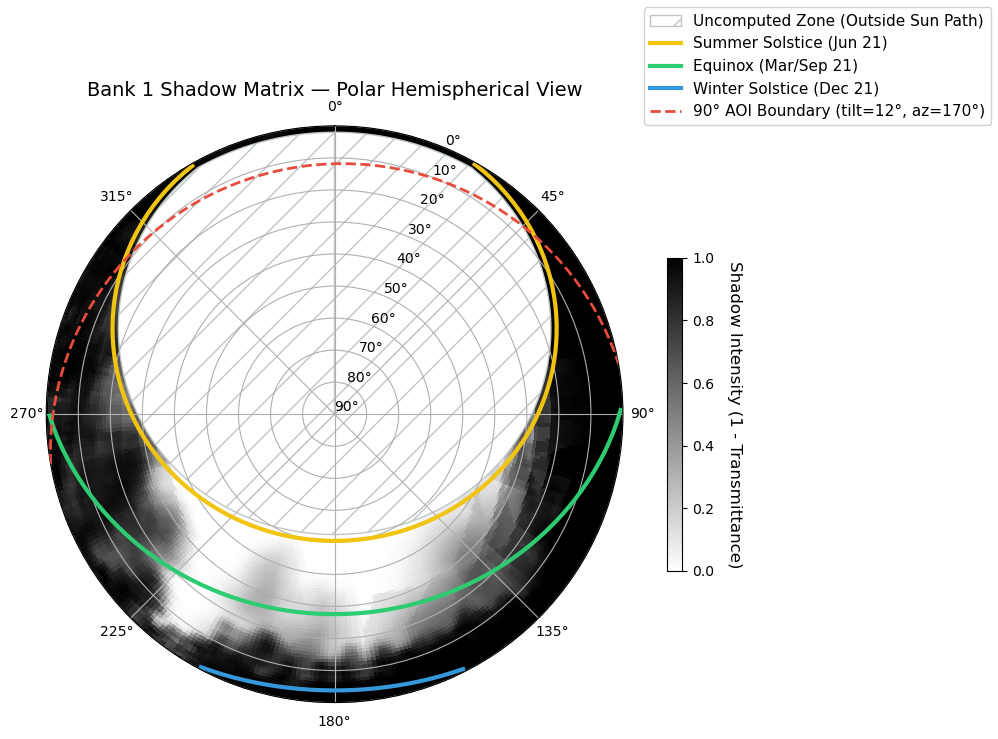

In [13]:
# %% --- 5. Visualise Shadow Matrix ---

if plot_shadow_matrix_with_sunpaths is not None:
    plot_shadow_matrix_with_sunpaths(
        SHADOW_CSV,
        fill_missing=True,
        save_path=str(MANUSCRIPT_FIG_DIR / "SAM_bank1.png"),
        show=True,
        dpi=300,
    )


In [14]:
# %% --- 6. Load Inverter Data ---
pv_df = load_inverter_data(PV_EXCEL, expected_interval_min=cfg.interval_minutes)
print(f"Range: {pv_df['Timestamp'].min()} -> {pv_df['Timestamp'].max()}")
print(pv_df.head())

Inverter data: 102,263 records, 102235/102262 normal intervals, 27 gaps
  Largest gaps: [965. 925. 905. 875. 825.] min
Range: 2021-01-01 00:00:00 -> 2021-12-31 23:55:00
            Timestamp  Energy_Wh  Power_W
0 2021-01-01 00:00:00        0.0      0.0
1 2021-01-01 00:05:00        0.0      0.0
2 2021-01-01 00:10:00        0.0      0.0
3 2021-01-01 00:15:00        0.0      0.0
4 2021-01-01 00:20:00        0.0      0.0


In [15]:
# %% --- 7. Single-Day Analysis (with manuscript plot) ---
day_data, forecast_base, forecast_windowed = pv_analysis(
    target_date=second_day,
    shadow_matrix=shadow_matrix,
    excel_df=pv_df,
    df_extra=extra_data_df,
    cfg=cfg,
    plot=False,
)

_plot_day_comparison(
    day_data,
    forecast_base,
    forecast_windowed,
    second_day,
    day_data.index,
    save_path=str(MANUSCRIPT_FIG_DIR / "b1_july04_timeseries.png"),
)


In [16]:
# %% --- 8. Single-Day Metrics ---
metrics_single = compute_metrics(day_data, forecast_base, forecast_windowed, cfg.interval_minutes)
print(f"\nMetrics for {second_day}:")
for k, v in metrics_single.items():
    if isinstance(v, float):
        print(f"  {k:15s}: {v:10.2f}")


Metrics for 2021-07-04:
  RMSE_Base      :     428.27
  RMSE_Shaded    :     187.43
  MAE_Base       :     303.94
  MAE_Shaded     :     121.81
  MBE_Base       :     290.72
  MBE_Shaded     :      11.23
  R2_Base        :       0.77
  R2_Shaded      :       0.96
  Real_Wh        :   17774.55
  Base_Wh        :   22862.16
  Shaded_Wh      :   17971.12


In [17]:
# %% --- Reviewer TODO: 07_results.tex §Case Study 4 July 2021 (~10:15) ---
# Diagnostic for the residual mismatch around 10:15 local time on 4 July 2021.
# Produces:
#   results/residual_diagnostic_b1_20210704_revised.png  — 2-panel plot
#   results/residual_diagnostic_b1_20210704_revised.csv  — data table
#
# PREREQUISITE: day_data, forecast_base, forecast_windowed, extra_data_df
#   must be in scope from the single-day analysis cells above (second_day = 2021-07-04).
#   Re-run those cells if the kernel was restarted.
#
# TODO[author]: After reviewing the diagnostic plot and CSV, add a sentence
#   to Section 7 (Results §Single-Day Case Study) explaining the physical
#   cause of the ~10:15 discrepancy. Check the irradiance (ghi/dhi/dni) and
#   power traces for cloud edges, thin cirrus, or other transient effects.
#   Do NOT interpret scientifically without checking the data first.

from pv_analysis_re import plot_residual_diagnostics
import os
os.makedirs("results", exist_ok=True)

diagnostic_df = plot_residual_diagnostics(
    day_data=day_data,
    forecast_base=forecast_base,
    forecast_windowed=forecast_windowed,
    df_extra=extra_data_df,      # UTC-indexed; shifted to local time inside the function
    cfg=cfg,
    target_time="2021-07-04 10:15",  # Local Helsinki time (EEST = UTC+3 in summer)
    window="90min",
    save_path="results/residual_diagnostic_b1_20210704_revised.png",
    table_path="results/residual_diagnostic_b1_20210704_revised.csv",
)

display_cols = [c for c in ["Measured_W", "Baseline_W", "ShadowCorrected_W",
                             "Residual_ShadowCorrected_W", "ghi", "dhi", "dni"]
                if c in diagnostic_df.columns]
print("\nDiagnostic window (+-90 min around 10:15 local time):")
print(diagnostic_df[display_cols].to_string())
print("\nOutput files:")
print("  results/residual_diagnostic_b1_20210704_revised.png")
print("  results/residual_diagnostic_b1_20210704_revised.csv")
print("\nTODO[author]: Interpret the irradiance and power data at ~10:15.")


Saved residual diagnostic table: results/residual_diagnostic_b1_20210704_revised.csv
Saved residual diagnostic plot: results/residual_diagnostic_b1_20210704_revised.png

Diagnostic window (+-90 min around 10:15 local time):
                     Measured_W   Baseline_W  ShadowCorrected_W  Residual_ShadowCorrected_W     ghi    dhi         dni
2021-07-04 08:45:00     1242.24  1733.485108        1160.583702                  -81.656298  486.34  67.96  822.719103
2021-07-04 08:50:00     1320.12  1762.690636        1159.803990                 -160.316010  496.24  68.38  827.745734
2021-07-04 08:55:00     1348.56  1794.349327        1307.495071                  -41.064929  504.46  69.44  828.322731
2021-07-04 09:00:00     1435.80  1828.246299        1342.452134                  -93.347866  514.56  69.26  834.862899
2021-07-04 09:05:00     1497.36  1860.283777        1528.060197                   30.700197  524.56  68.86  841.564312
2021-07-04 09:10:00     1583.40  1889.623573        1610.94269

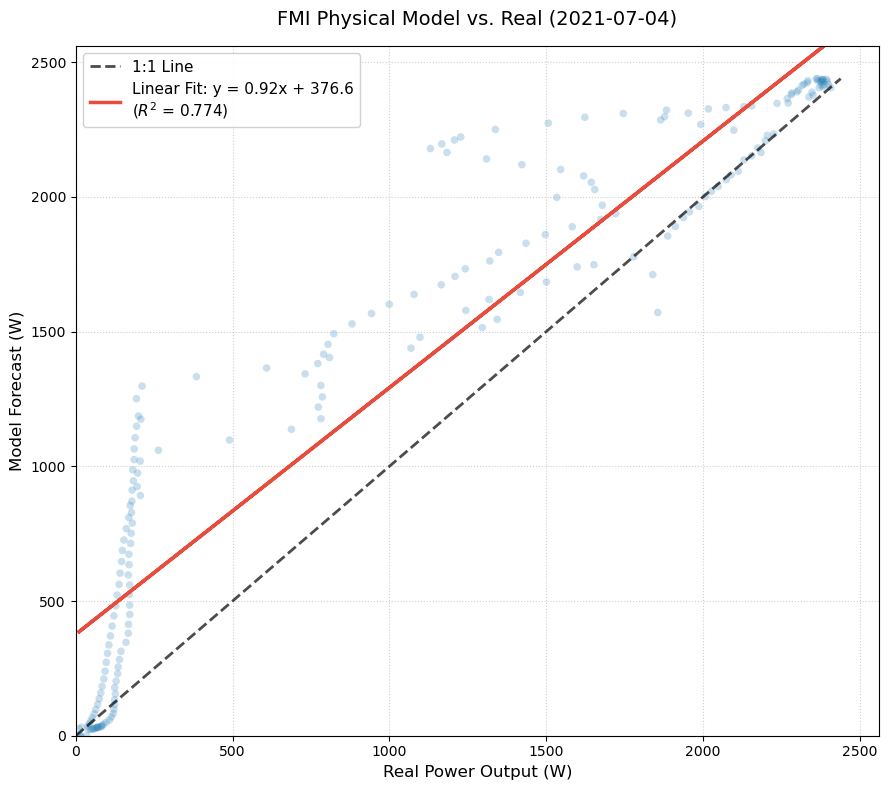

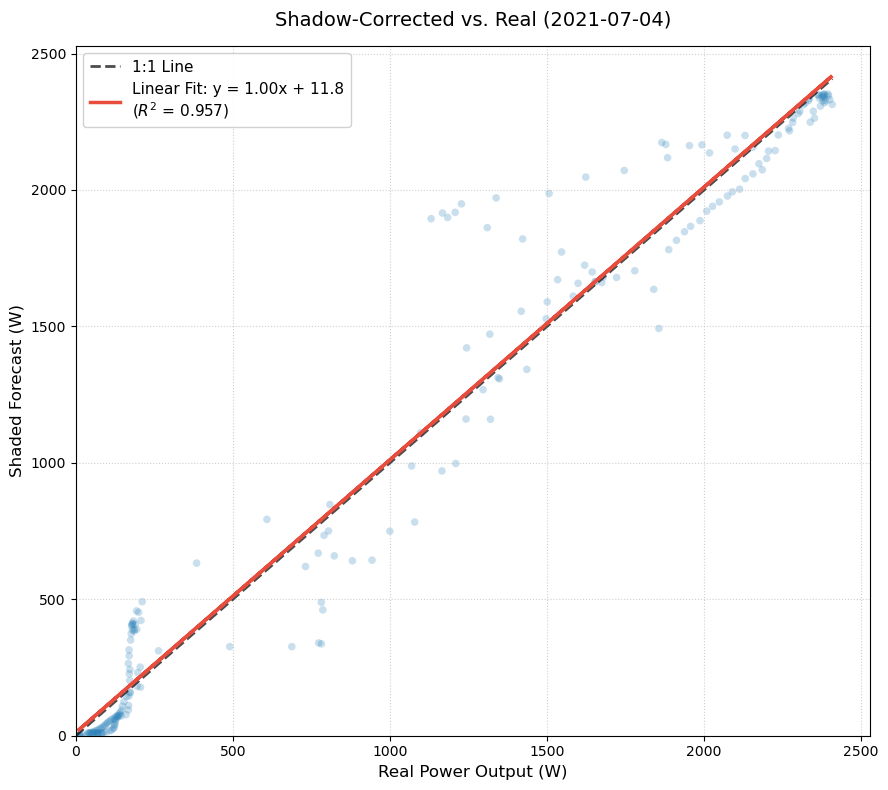

In [18]:
# %% --- 9. Scatter Plots for Single Day ---
plot_real_vs_predicted_scatter(
    day_data["Power_W"].values,
    forecast_base["output"].values,
    title=f"FMI Physical Model vs. Real ({second_day})",
    ylabel="Model Forecast (W)",
    power_threshold=10.0,
)

plot_real_vs_predicted_scatter(
    day_data["Power_W"].values,
    forecast_windowed["output_shaded"].values,
    title=f"Shadow-Corrected vs. Real ({second_day})",
    ylabel="Shaded Forecast (W)",
    power_threshold=10.0,
)

Evaluating: 100%|██████████| 10/10 [00:00<00:00, 29.30it/s]



Generating scatter plots...


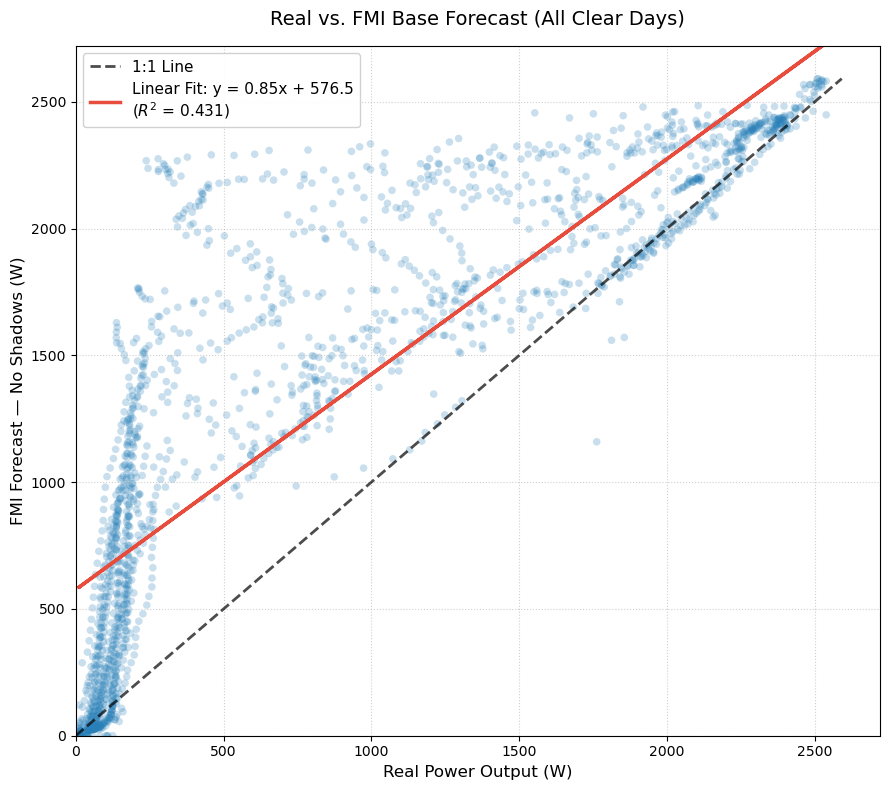

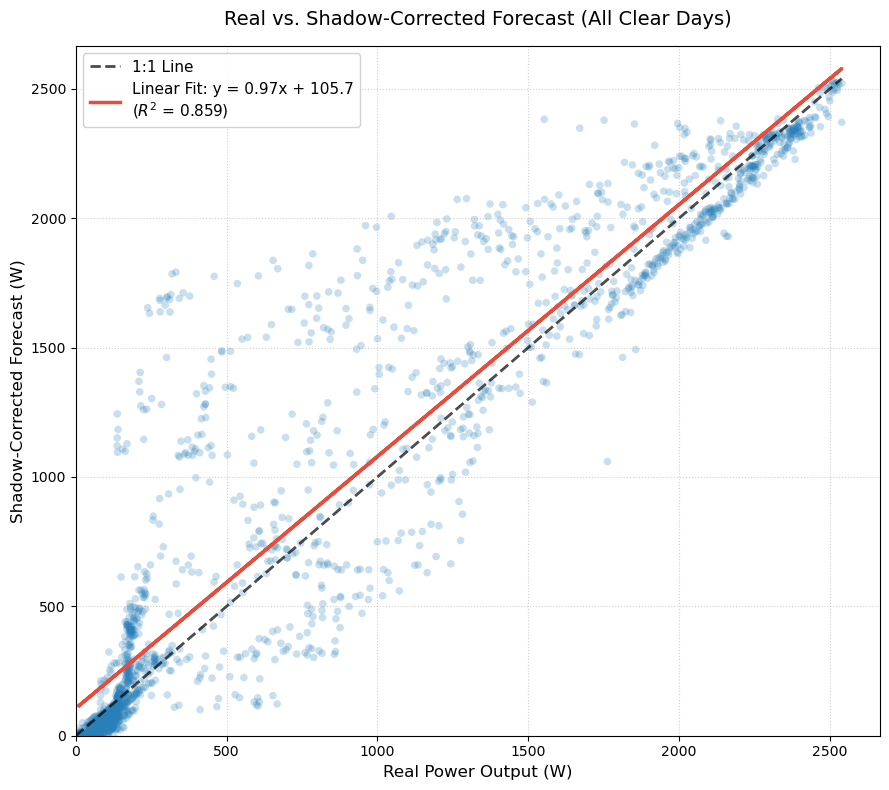


  PV FORECAST PERFORMANCE METRICS (CLEAR DAYS)

  RMSE  Base:     628.88 W
  RMSE  Shaded:   312.94 W  (+50.2%)

  MAE   Base:     476.91 W
  MAE   Shaded:   195.33 W  (+59.0%)

  MBE   Base:    +467.39 W
  MBE   Shaded:   +96.48 W

  R2    Base:      0.431
  R2    Shaded:    0.859

  --- Energy Yield ---
  Real:      134.05 kWh
  Base:      201.64 kWh  (+50.4%)
  Shaded:    146.61 kWh  (+9.4%)


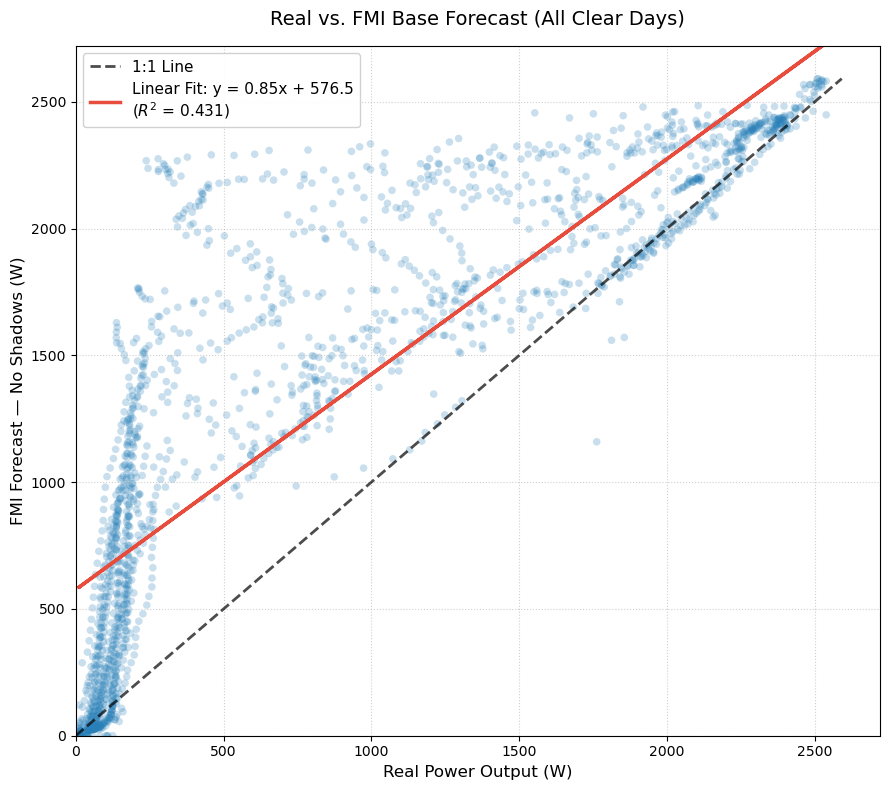

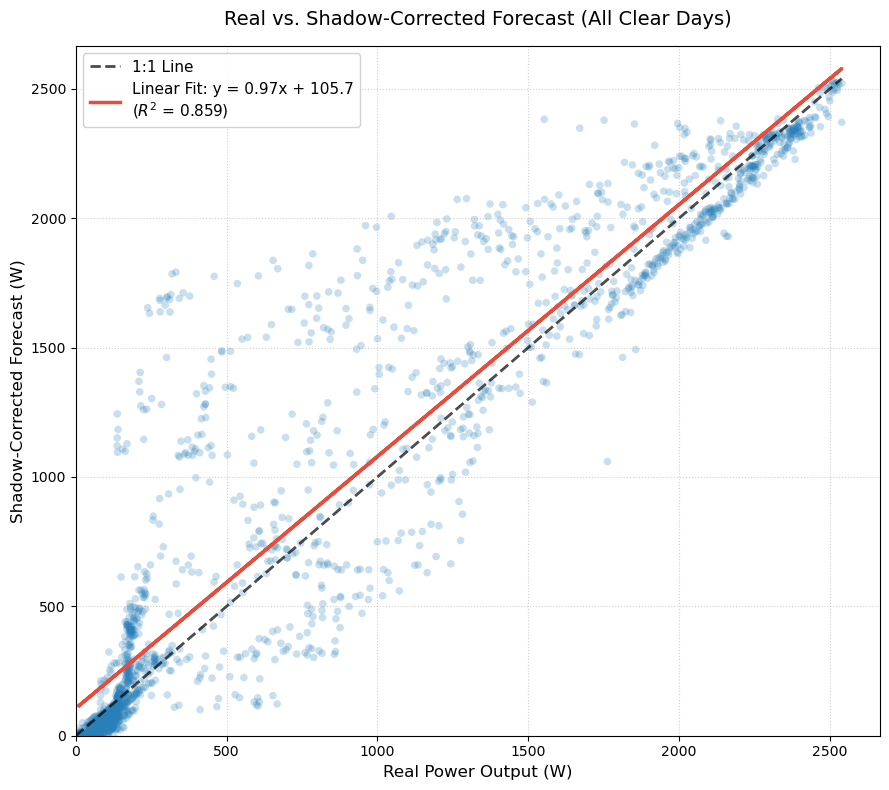

In [19]:
# %% --- 10. Multi-Day Batch Evaluation ---
# def _load_cached_extra(date_obj):
#     """Load pre-cached extra_data CSV for a date, recomputing albedo."""
#     try:
#         return load_extra_data_csv(
#             f"{EXTRA_DATA_DIR}/extra_data_{date_obj}.csv", cfg=cfg
#         )
#     except FileNotFoundError:
#         print(f"  Warning: No extra data for {date_obj}, skipping.")
#         return None

def _load_cached_extra(date_obj):
    df = load_extra_data_csv(f"output/extra_data_{date_obj}.csv")
    df = replace_dni_with_computed(df, cfg.latitude, cfg.longitude)
    return df


results_df, all_real, all_pred_shaded, all_pred_base = evaluate_performance(
    significant_days_df=clear_days_fraction,
    shadow_matrix=shadow_matrix,
    excel_df=pv_df,
    extra_data_loader=_load_cached_extra,
    cfg=cfg,
)

print_performance_summary(results_df, real_arr=all_real, base_arr=all_pred_base, shaded_arr=all_pred_shaded)

if not results_df.empty:
    plot_real_vs_predicted_scatter(
        all_real,
        all_pred_base,
        title="Real vs. FMI Base Forecast (All Clear Days)",
        ylabel="FMI Forecast — No Shadows (W)",
        power_threshold=10.0,
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_scatter_base.png"),
    )
    plot_real_vs_predicted_scatter(
        all_real,
        all_pred_shaded,
        title="Real vs. Shadow-Corrected Forecast (All Clear Days)",
        ylabel="Shadow-Corrected Forecast (W)",
        power_threshold=10.0,
        save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_scatter_corr.png"),
    )

In [20]:
# # %% --- 10b. Save All Daily Comparison Plots ---
save_all_day_plots(
    significant_days_df=clear_days_fraction,
    shadow_matrix=shadow_matrix,
    excel_df=pv_df,
    extra_data_loader=_load_cached_extra,
    output_dir="results/daily_plots_10_b1",
    cfg=cfg,
)

# save all day plots with radiation curves

# for target_date in clear_days["Date"]:
    
#     day_data, fb_n, fw_n = pv_analysis(target_date, shadow_matrix, excel_df, df_extra, cfg)
# plot_radiation_day(
#     "output/extra_data_2021-04-17.csv",
#     date="2021-04-17",
#     day_data=day_data, fb_n=fb_n, fw_n=fw_n,
#     save_path="radiation_pv_2021-04-17.png",
# )


# batch_day_plots(
#     clear_days=clear_days,
#     shadow_matrix=shadow_matrix,
#     excel_df=pv_df,
#     extra_data_loader=load_extra,
#     extra_csv_pattern="output/extra_data_{date}.csv",
#     cfg=cfg,
#     output_dir="day_plots",
# )

Saving daily plots: 100%|██████████| 10/10 [00:02<00:00,  4.63it/s]


Saved 10 daily plots to results/daily_plots_10_b1/


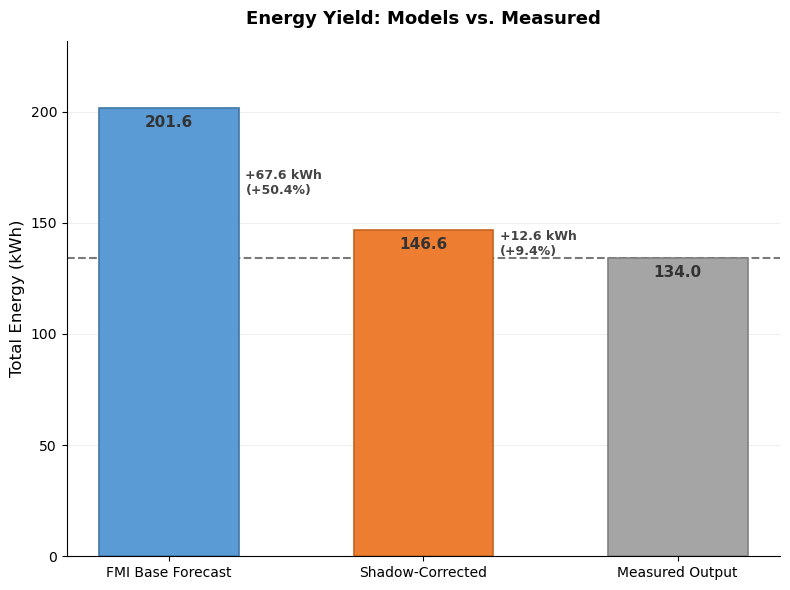

In [21]:
# %% --- 11. Energy Yield Bar Chart ---
def plot_energy_bar_chart(results_df: pd.DataFrame, save_path=None):
    """Comparative bar chart: clearsky vs corrected vs real energy yield."""
    totals = results_df[["Real_Wh", "Base_Wh", "Shaded_Wh"]].sum() / 1000

    labels = ["FMI Base Forecast", "Shadow-Corrected", "Measured Output"]
    values = [totals["Base_Wh"], totals["Shaded_Wh"], totals["Real_Wh"]]
    target = values[2]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Muted, professional palette
    colors = ["#5B9BD5", "#ED7D31", "#A5A5A5"]
    edge_colors = ["#4178A4", "#C46420", "#808080"]
    bars = ax.bar(labels, values, color=colors, edgecolor=edge_colors,
                  width=0.55, linewidth=1.2, zorder=3)

    # Reference line
    ax.axhline(y=target, color="#404040", ls="--", lw=1.5, alpha=0.7, zorder=2)
    # ax.text(2.35, target, f"{target:,.2f} kWh", va="center", fontsize=9,
    #         color="#404040", fontstyle="italic")

    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h - max(values) * 0.015,
                f"{h:,.2f}", ha="center", va="top", fontsize=11, fontweight="bold",
                color="#333333")

    # Error annotations for first two bars
    for i in range(2):
        err = values[i] - target
        cx = bars[i].get_x() + bars[i].get_width() / 2
        h = bars[i].get_height()
        sign = "+" if err >= 0 else ""
        err_pct = err / target * 100

        # Small annotation to the right of each bar
        ax.annotate(
            f"{sign}{err:.2f} kWh\n({sign}{err_pct:.2f}%)",
            xy=(cx + 0.3, (h + target) / 2),
            fontsize=9, color="#444444", ha="left", va="center",
            fontweight="bold",
        )
        # Thin bracket line
        # ax.plot([cx + 0.25, cx + 0.25], [min(h, target), max(h, target)],
        #         color="#999999", lw=1, zorder=4)

    ax.set_ylabel("Total Energy (kWh)", fontsize=12)
    ax.set_title("Energy Yield: Models vs. Measured", fontsize=13, pad=12, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.tick_params(axis="both", labelsize=10)

    # n_days = len(results_df)
    # ax.text(0.02, 0.97, f"{n_days} clear days", transform=ax.transAxes,
    #         fontsize=9, va="top", color="#888888")

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()



if not results_df.empty:
    plot_energy_bar_chart(results_df, save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_energy.png"))

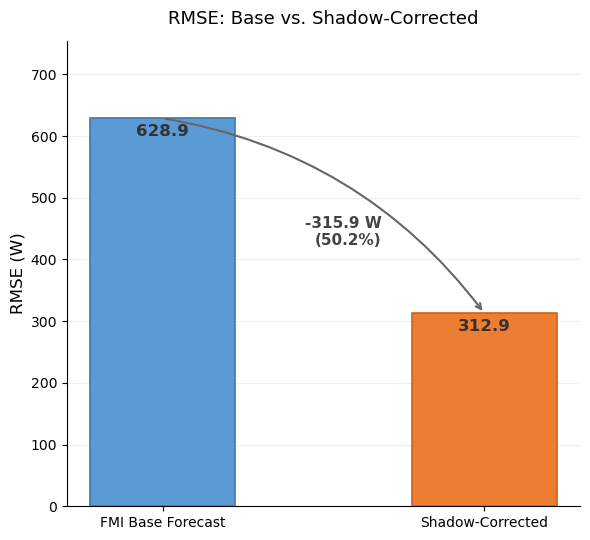

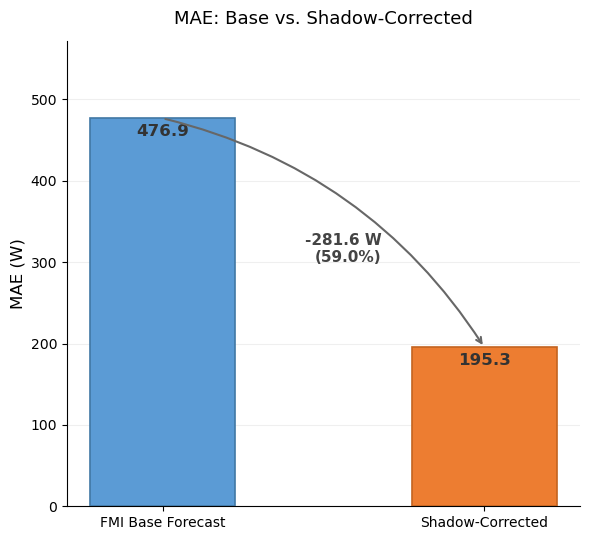

In [22]:
# %% --- 12. RMSE & MAE Bar Charts ---
def _plot_metric_comparison(base_val, shaded_val, metric_name, unit="W",
                            results_df=None):
    """Generic paired bar chart for a single metric, matching energy chart style."""
    imp = base_val - shaded_val
    imp_pct = (imp / base_val) * 100 if base_val != 0 else 0

    labels = ["FMI Base Forecast", "Shadow-Corrected"]
    values = [base_val, shaded_val]

    fig, ax = plt.subplots(figsize=(6, 5.5))

    colors = ["#5B9BD5", "#ED7D31"]
    edge_colors = ["#4178A4", "#C46420"]
    bars = ax.bar(labels, values, color=colors, edgecolor=edge_colors,
                  width=0.45, linewidth=1.2, zorder=3)

    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h - max(values) * 0.015,
                f"{h:,.2f}", ha="center", va="top", fontsize=12,
                fontweight="bold", color="#333333")

    # Improvement annotation with arrow between bar tops
    cx0 = bars[0].get_x() + bars[0].get_width() / 2
    cx1 = bars[1].get_x() + bars[1].get_width() / 2
    mid_x = (cx0 + cx1) / 2
    mid_y = (values[0] + values[1]) / 2

    ax.annotate(
        "", xy=(cx1, values[1]), xytext=(cx0, values[0]),
        arrowprops=dict(arrowstyle="->", color="#676767", lw=1.5,
                        connectionstyle="arc3,rad=-0.2"),
        zorder=4,
    )
    ax.text(mid_x + 0.18, mid_y,
            f"-{imp:.2f} {unit}\n({imp_pct:.2f}%)",
            fontsize=11, color="#444444", ha="right", va="top",
            fontweight="bold")

    ax.set_ylabel(f"{metric_name} ({unit})", fontsize=12)
    ax.set_title(f"{metric_name}: Base vs. Shadow-Corrected", fontsize=13, pad=12)
    ax.set_ylim(0, max(values) * 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.tick_params(axis="x", labelsize=10)

    plt.tight_layout()
    plt.show()


if not results_df.empty:
    _plot_metric_comparison(
        results_df["RMSE_Base"].mean(),
        results_df["RMSE_Shaded"].mean(),
        "RMSE", "W", results_df,
    )
    _plot_metric_comparison(
        results_df["MAE_Base"].mean(),
        results_df["MAE_Shaded"].mean(),
        "MAE", "W", results_df,
    )

Saved: results/slope_b1.png


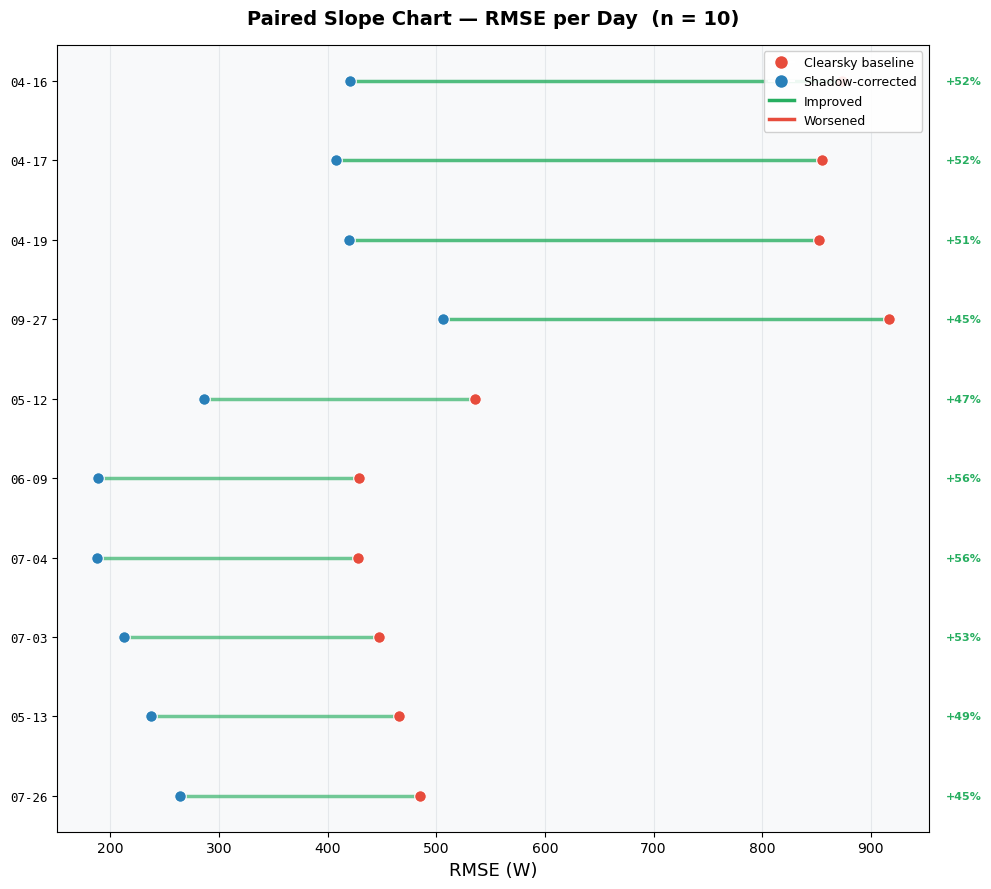

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b1_clearsky_ridgeline.png


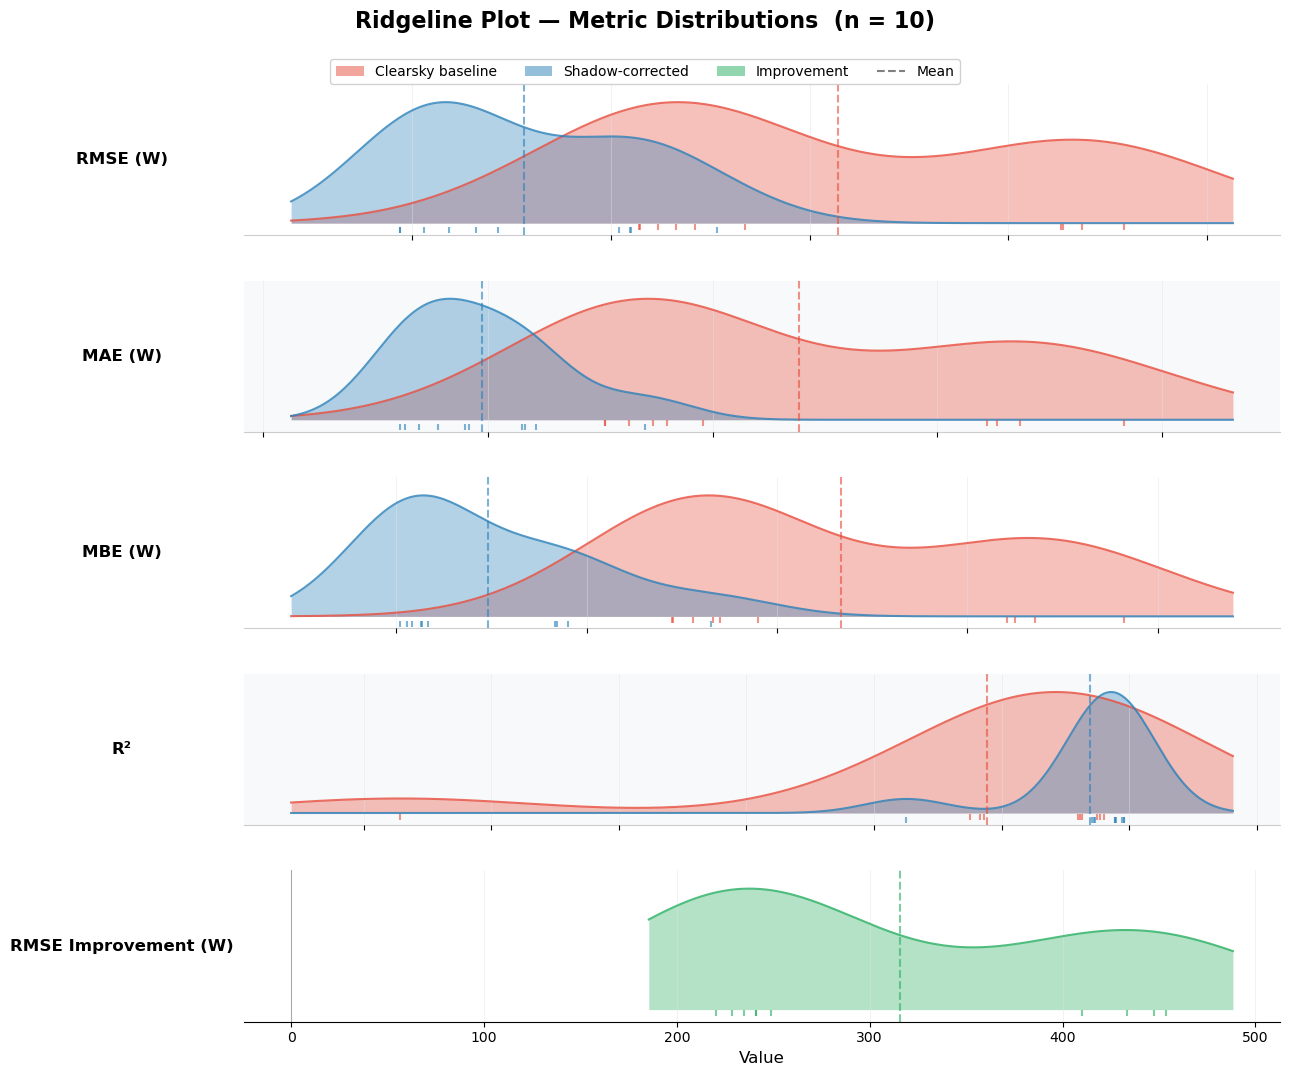

Saved: results/energy_slope_b1.png


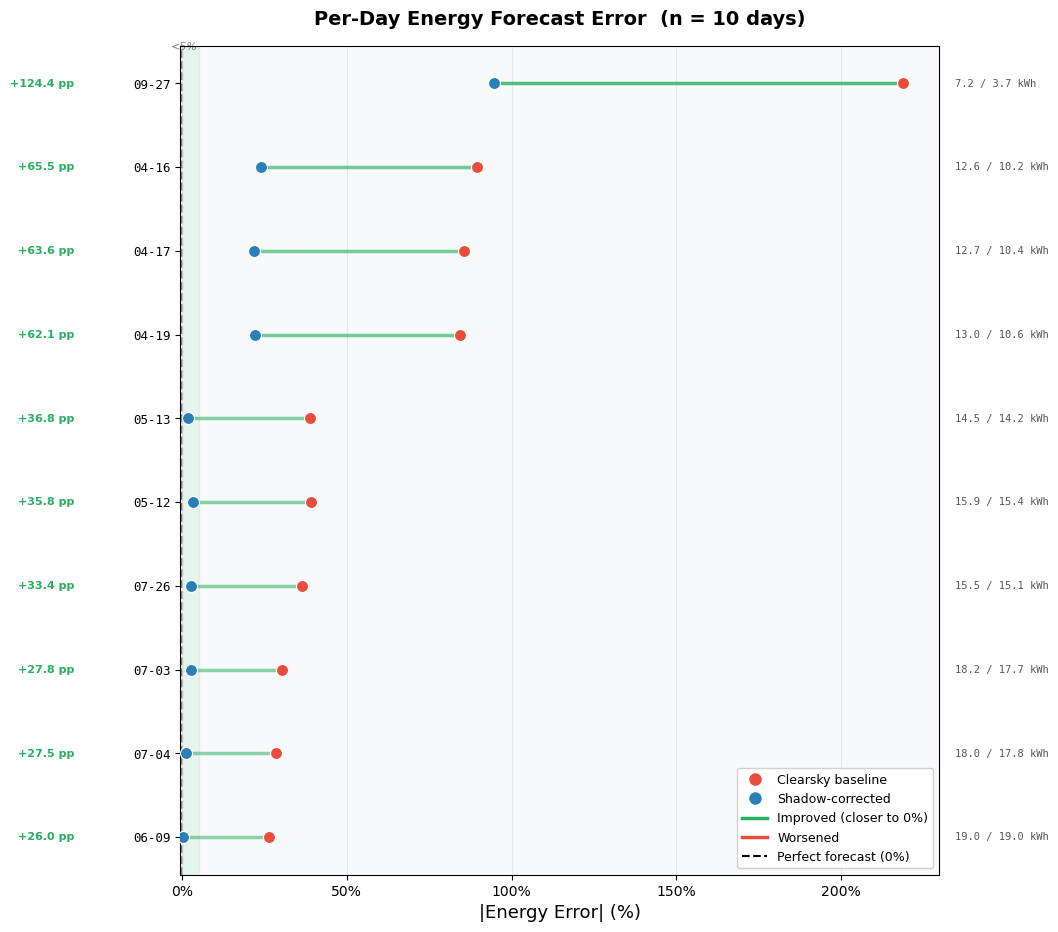

Saved: results/energy_slope_pct_b1.png


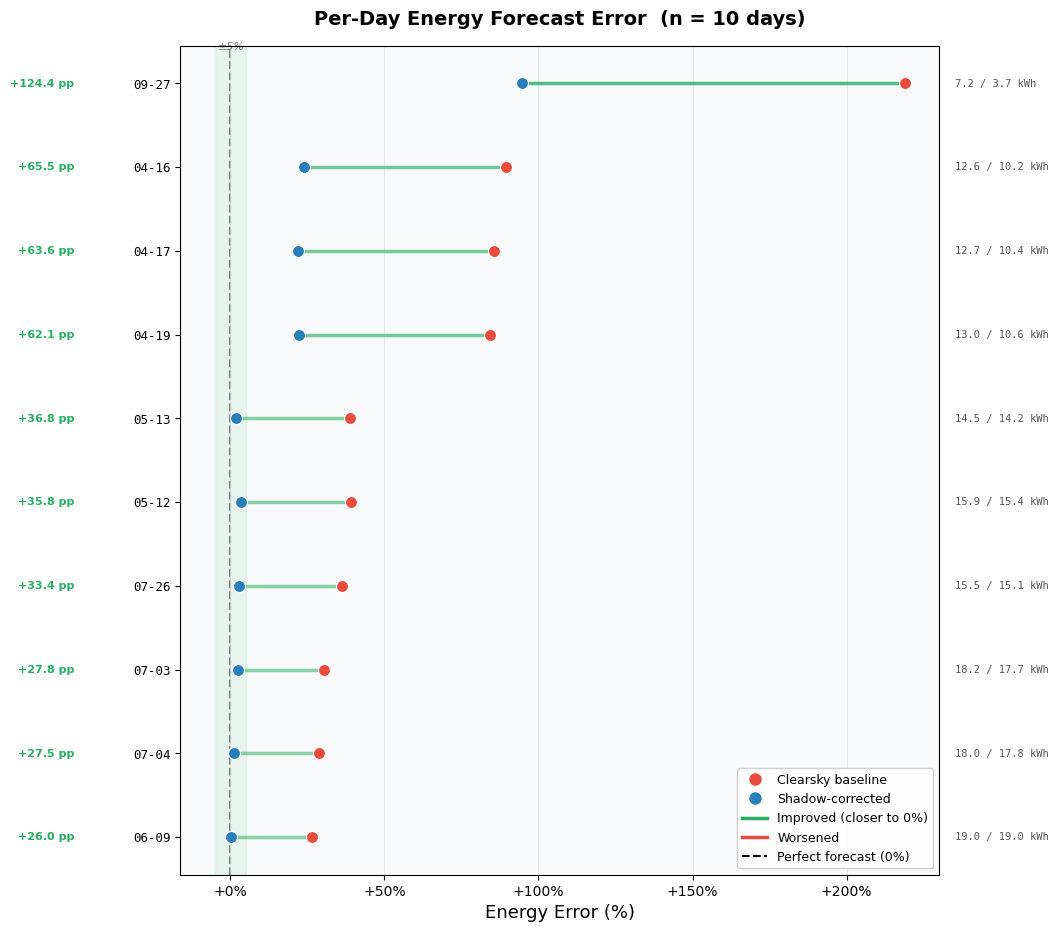

In [23]:
from plot_daily_distributions import (
    plot_raincloud, plot_paired_slope, plot_ridgeline, plot_energy_slope
)
# _ = plot_raincloud(results_df, save_path="results/plots_b1/raincloud_b1.png", figsize=(10, 10))
_ = plot_paired_slope(results_df, save_path="results/slope_b1.png")
_ = plot_ridgeline(results_df, save_path=str(MANUSCRIPT_FIG_DIR / "b1_clearsky_ridgeline.png"), dpi=300, figsize=(13, 10.5))
_ = plot_energy_slope(results_df, use_absolute=True, save_path="results/energy_slope_b1.png")
_ = plot_energy_slope(results_df, use_absolute=False, save_path="results/energy_slope_pct_b1.png")